# Cohort Retention Analysis on Brazilian E-Commerce (SQL)

This project analyzes monthly customer retention using the Brazilian E-Commerce Public Dataset by Olist.

The goal is to assign each customer to a cohort based on their first purchase month, measure customer activity in the following months, build a cohort retention matrix, calculate retention rates, and analyze the overall retention curve.

The cohort and period calculations are performed in SQL using SQLite. Python and pandas are used to load the data and display SQL results, while seaborn and matplotlib are used for visualization.

In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")

In [3]:
customers.shape, orders.shape, order_items.shape

((99441, 5), (99441, 8), (112650, 7))

In [4]:
conn = sqlite3.connect("cohort_retention.db")

In [5]:
customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

order_items.to_sql(
    "order_items",
    conn,
    if_exists="replace",
    index=False
)

112650

### Verify SQL Tables

The database is checked to confirm that all required tables were created successfully.

In [6]:
pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
    """,
    conn
)

,name
0,customers
1,orders
2,order_items


In [46]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [47]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [48]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


## Q1 — Restrict to Delivered Orders

Only orders with `order_status = 'delivered'` are included in the cohort retention analysis.

In [7]:
q1 = """
SELECT
    order_id,
    customer_id,
    order_purchase_timestamp
FROM orders
WHERE order_status = 'delivered';
"""

delivered_orders = pd.read_sql_query(q1, conn)

delivered_orders.head()

,order_id,customer_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39


In [8]:
delivered_orders.shape

(96478, 3)

## Q2 — Cohort Assignment

For each customer, the earliest purchase month is identified as the `cohort_month`.


In [9]:
q2 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        o.order_purchase_timestamp,
        c.customer_unique_id
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

customer_cohorts AS (
    SELECT DISTINCT customer_unique_id,
        MIN( strftime('%Y-%m', order_purchase_timestamp)) OVER (PARTITION BY customer_unique_id) AS cohort_month
    FROM delivered_orders
)

SELECT *
FROM customer_cohorts
ORDER BY cohort_month, customer_unique_id;
"""

cohorts = pd.read_sql_query(q2, conn)

cohorts.head(10)

,customer_unique_id,cohort_month
0,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09
1,0032c76b20340da25249092a268ce66c,2016-10
2,01f156677184504063bd19739f924af1,2016-10
3,0636d30c77f0f9cfad81f1c9b58c791f,2016-10
4,06bdfbbe1857c3c925ec81abfb1c9666,2016-10
5,0829f7df6577d5a4b65439bea701405f,2016-10
6,08da95f931937b2c20f5225f2e6c93b0,2016-10
7,0922f37485310929b1b94e8f0c984ca5,2016-10
8,0a02ba4243b1b0e048a3841d5758d113,2016-10
9,0ac6c084c9623a0e2ace60297ad24d6c,2016-10


In [10]:
cohorts.shape

(93358, 2)

In [11]:
cohorts["customer_unique_id"].nunique()

93358

## Q3 — Create Customer Activity


For every delivered order, the customer's stable identifier (`customer_unique_id`), order ID, and order month are retained.

In [12]:
q3 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        o.order_purchase_timestamp,
        c.customer_unique_id
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

activity AS (
    SELECT
        customer_unique_id,
        order_id,
        strftime('%Y-%m', order_purchase_timestamp) AS order_month
    FROM delivered_orders
)

SELECT *
FROM activity
ORDER BY customer_unique_id, order_month;
"""

activity = pd.read_sql_query(q3, conn)

activity.head(10)

,customer_unique_id,order_id,order_month
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11
5,0004bd2a26a76fe21f786e4fbd80607f,3e470077b690ea3e3d501cffb5e0c499,2018-04
6,00050ab1314c0e55a6ca13cf7181fecf,d0028facea13f508e880202d7097a5a1,2018-04
7,00053a61a98854899e70ed204dd4bafe,44e608f2db00c74a1fe329de44416a4e,2018-02
8,0005e1862207bf6ccc02e4228effd9a0,ae76bef74b97bcb0b3e355e60d9a6f9c,2017-03
9,0005ef4cd20d2893f0d9fbd94d3c0d97,01b330808c5819a6a3cb79b72f0b8288,2018-03


In [13]:
activity.shape

(96478, 3)

## Q4 — Calculate the Period Number


A customer's cohort month is assigned `period_number = 0`.
The calculation is performed in SQL using calendar-month arithmetic so that differences across different years are handled correctly.

In [15]:
q4 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        o.order_purchase_timestamp,
        c.customer_unique_id
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

activity AS (
    SELECT
        customer_unique_id,
        order_id,
        strftime('%Y-%m',order_purchase_timestamp) AS order_month
    FROM delivered_orders
),

customer_cohorts AS (
    SELECT DISTINCT customer_unique_id, MIN(strftime('%Y-%m', order_purchase_timestamp)) OVER (PARTITION BY customer_unique_id) AS cohort_month
    FROM delivered_orders
),

customer_activity AS (
    SELECT
        a.customer_unique_id,
        c.cohort_month,
        a.order_id,
        a.order_month,
        ((CAST(substr(a.order_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(a.order_month, 6, 2) AS INTEGER))
            -
            (CAST(substr(c.cohort_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(c.cohort_month, 6, 2) AS INTEGER))) AS period_number

    FROM activity a
    JOIN customer_cohorts c
        ON a.customer_unique_id = c.customer_unique_id
)

SELECT *
FROM customer_activity
ORDER BY customer_unique_id, order_month;
"""

customer_activity = pd.read_sql_query(q4, conn)

customer_activity.head(20)

,customer_unique_id,cohort_month,order_id,order_month,period_number
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05,e22acc9c116caa3f2b7121bbb380d08e,2018-05,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05,3594e05a005ac4d06a72673270ef9ec9,2018-05,0
2,0000f46a3911fa3c0805444483337064,2017-03,b33ec3b699337181488304f362a6b734,2017-03,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10,41272756ecddd9a9ed0180413cc22fb6,2017-10,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11,d957021f1127559cd947b62533f484f7,2017-11,0
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04,3e470077b690ea3e3d501cffb5e0c499,2018-04,0
6,00050ab1314c0e55a6ca13cf7181fecf,2018-04,d0028facea13f508e880202d7097a5a1,2018-04,0
7,00053a61a98854899e70ed204dd4bafe,2018-02,44e608f2db00c74a1fe329de44416a4e,2018-02,0
8,0005e1862207bf6ccc02e4228effd9a0,2017-03,ae76bef74b97bcb0b3e355e60d9a6f9c,2017-03,0
9,0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03,01b330808c5819a6a3cb79b72f0b8288,2018-03,0


In [18]:
customer_activity[customer_activity["period_number"] != 0].head(20)

,customer_unique_id,cohort_month,order_id,order_month,period_number
105,004288347e5e88a27ded2bb23747066c,2017-07,08204559bebd39e09ee52dcb56d8faa2,2018-01,6
245,00a39521eb40f7012db50455bf083460,2018-05,cea3e6c11eb60acb9d8d4d51694832f8,2018-06,1
408,011575986092c30523ecb71ff10cb473,2018-02,ed0a6265b5b0a292cd537214f401f1fc,2018-04,2
424,011b4adcd54683b480c4d841250a987f,2017-08,93b35affb86435b71ca01a6dd1eab2b1,2018-02,6
434,012452d40dafae4df401bced74cdb490,2017-06,e49d0607832db7c3b1343764225d8df6,2018-05,11
445,012a218df8995d3ec3bb221828360c86,2018-05,207258d556f9b9784b54de837ae49286,2018-06,1
475,013ef03e0f3f408dd9bf555e4edcdc0a,2018-06,00cee8a4dbb042385cbbd84699e78b2e,2018-07,1
511,015557c9912277312b9073947804a7ba,2017-03,48d9d778ca005971949d2ccad7e99d70,2017-05,2
556,0178b244a5c281fb2ade54038dd4b161,2017-05,94ca38619d7e64f94facac403a99682d,2018-07,14
588,01886ef98f995e4f2dd75a1d04c97397,2017-11,ce8d55aa1c206156fde37e062c716ea2,2018-03,4


## Q5 — Build the Retention Matrix

Each row represents a cohort month, while each column represents the number of months elapsed since the cohort's first purchase

In [19]:
q5 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        o.order_purchase_timestamp,
        c.customer_unique_id
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

activity AS (
    SELECT
        customer_unique_id,
        order_id,
        strftime('%Y-%m', order_purchase_timestamp) AS order_month
    FROM delivered_orders
),

customer_cohorts AS (
    SELECT DISTINCT customer_unique_id,
        MIN(strftime('%Y-%m', order_purchase_timestamp)) OVER ( PARTITION BY customer_unique_id ) AS cohort_month
    FROM delivered_orders
),

customer_activity AS (
    SELECT
        a.customer_unique_id,
        c.cohort_month,
        a.order_id,
        a.order_month,
        ( (CAST(substr(a.order_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(a.order_month, 6, 2) AS INTEGER))
            -
            (CAST(substr(c.cohort_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(c.cohort_month, 6, 2) AS INTEGER))) AS period_number

    FROM activity a
    JOIN customer_cohorts c
        ON a.customer_unique_id = c.customer_unique_id
),

retention_matrix AS (
    SELECT
        cohort_month,
        period_number,
        COUNT(DISTINCT customer_unique_id) AS customer_count
    FROM customer_activity
    GROUP BY
        cohort_month,
        period_number
)

SELECT *
FROM retention_matrix
ORDER BY
    cohort_month,
    period_number;
"""

retention_matrix = pd.read_sql_query(q5, conn)

retention_matrix.head(20)

,cohort_month,period_number,customer_count
0,2016-09,0,1
1,2016-10,0,262
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1
5,2016-10,13,1
6,2016-10,15,1
7,2016-10,17,1
8,2016-10,19,2
9,2016-10,20,2


In [20]:
retention_matrix.shape

(219, 3)

In [21]:
retention_matrix[retention_matrix["period_number"] == 0].head(20)

,cohort_month,period_number,customer_count
0,2016-09,0,1
1,2016-10,0,262
10,2016-12,0,1
12,2017-01,0,717
30,2017-02,0,1628
48,2017-03,0,2503
66,2017-04,0,2256
83,2017-05,0,3451
99,2017-06,0,3037
114,2017-07,0,3752


## Q6 — Calculate Cohort Size

Since period 0 corresponds to the customer's cohort month, the cohort size is calculated by selecting the `period_number = 0` records from the retention matrix.

In [22]:
q6 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        o.order_purchase_timestamp,
        c.customer_unique_id
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

activity AS (
    SELECT
        customer_unique_id,
        order_id,
        strftime('%Y-%m', order_purchase_timestamp ) AS order_month
    FROM delivered_orders
),

customer_cohorts AS (
    SELECT DISTINCT
        customer_unique_id,
        MIN(strftime('%Y-%m', order_purchase_timestamp)) OVER (PARTITION BY customer_unique_id) AS cohort_month
    FROM delivered_orders
),

customer_activity AS (
    SELECT
        a.customer_unique_id,
        c.cohort_month,
        a.order_id,
        a.order_month,
        ((CAST(substr(a.order_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(a.order_month, 6, 2) AS INTEGER))
            -
            (CAST(substr(c.cohort_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(c.cohort_month, 6, 2) AS INTEGER))) AS period_number

    FROM activity a
    JOIN customer_cohorts c
        ON a.customer_unique_id = c.customer_unique_id
),

retention_matrix AS (
    SELECT
        cohort_month,
        period_number,
        COUNT(DISTINCT customer_unique_id) AS customer_count
    FROM customer_activity
    GROUP BY
        cohort_month,
        period_number
),

cohort_size AS (
    SELECT
        cohort_month,
        customer_count AS cohort_size
    FROM retention_matrix
    WHERE period_number = 0
)

SELECT *
FROM cohort_size
ORDER BY cohort_month;
"""

cohort_size = pd.read_sql_query(q6, conn)

cohort_size.head(20)

,cohort_month,cohort_size
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,717
4,2017-02,1628
5,2017-03,2503
6,2017-04,2256
7,2017-05,3451
8,2017-06,3037
9,2017-07,3752


In [23]:
cohort_size.shape

(23, 2)

## Q7 — Calculate the Retention Rate Matrix

The retention rate is calculated by dividing the number of active customers in a given period by the original cohort size and multiplying by 100.
The cohort's period 0 retention rate is therefore 100%

In [24]:
q7 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        o.order_purchase_timestamp,
        c.customer_unique_id
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

activity AS (
    SELECT
        customer_unique_id,
        order_id,
        strftime( '%Y-%m', order_purchase_timestamp ) AS order_month
    FROM delivered_orders
),

customer_cohorts AS (
    SELECT DISTINCT
        customer_unique_id,
        MIN( strftime('%Y-%m', order_purchase_timestamp)) OVER ( PARTITION BY customer_unique_id) AS cohort_month
    FROM delivered_orders
),

customer_activity AS (
    SELECT
        a.customer_unique_id,
        c.cohort_month,
        a.order_id,
        a.order_month,
        ((CAST(substr(a.order_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(a.order_month, 6, 2) AS INTEGER))
            -
            (CAST(substr(c.cohort_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(c.cohort_month, 6, 2) AS INTEGER))) AS period_number

    FROM activity a
    JOIN customer_cohorts c
        ON a.customer_unique_id = c.customer_unique_id
),

retention_matrix AS (
    SELECT
        cohort_month,
        period_number,
        COUNT(DISTINCT customer_unique_id) AS customer_count
    FROM customer_activity
    GROUP BY
        cohort_month,
        period_number
),

cohort_size AS (
    SELECT
        cohort_month,
        customer_count AS cohort_size
    FROM retention_matrix
    WHERE period_number = 0
),

retention_rates AS (
    SELECT
        r.cohort_month,
        r.period_number,
        r.customer_count,
        c.cohort_size,
        ROUND(r.customer_count * 100.0 / c.cohort_size,2) AS retention_rate
    FROM retention_matrix r
    JOIN cohort_size c
        ON r.cohort_month = c.cohort_month
)

SELECT *
FROM retention_rates
ORDER BY
    cohort_month,
    period_number;
"""

retention_rates = pd.read_sql_query(q7, conn)

retention_rates.head(20)

,cohort_month,period_number,customer_count,cohort_size,retention_rate
0,2016-09,0,1,1,100.00
1,2016-10,0,262,262,100.00
2,2016-10,6,1,262,0.38
3,2016-10,9,1,262,0.38
4,2016-10,11,1,262,0.38
5,2016-10,13,1,262,0.38
6,2016-10,15,1,262,0.38
7,2016-10,17,1,262,0.38
8,2016-10,19,2,262,0.76
9,2016-10,20,2,262,0.76


In [25]:
retention_rates.shape

(219, 5)

In [26]:
retention_rates[
    retention_rates["period_number"] == 0
].head(20)

,cohort_month,period_number,customer_count,cohort_size,retention_rate
0,2016-09,0,1,1,100.0
1,2016-10,0,262,262,100.0
10,2016-12,0,1,1,100.0
12,2017-01,0,717,717,100.0
30,2017-02,0,1628,1628,100.0
48,2017-03,0,2503,2503,100.0
66,2017-04,0,2256,2256,100.0
83,2017-05,0,3451,3451,100.0
99,2017-06,0,3037,3037,100.0
114,2017-07,0,3752,3752,100.0


## Q8 — Calculate Average Retention by Period

This provides an overall view of how customer retention changes as more months pass after the initial purchase.

In [27]:
q8 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        o.order_purchase_timestamp,
        c.customer_unique_id
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

activity AS (
    SELECT
        customer_unique_id,
        order_id,
        strftime('%Y-%m', order_purchase_timestamp ) AS order_month
    FROM delivered_orders
),

customer_cohorts AS (
    SELECT DISTINCT
        customer_unique_id,
        MIN( strftime('%Y-%m', order_purchase_timestamp)) OVER (
            PARTITION BY customer_unique_id
        ) AS cohort_month
    FROM delivered_orders
),

customer_activity AS (
    SELECT
        a.customer_unique_id,
        c.cohort_month,
        a.order_id,
        a.order_month,
        ((CAST(substr(a.order_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(a.order_month, 6, 2) AS INTEGER))
            -
            (CAST(substr(c.cohort_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(c.cohort_month, 6, 2) AS INTEGER))) AS period_number

    FROM activity a
    JOIN customer_cohorts c
        ON a.customer_unique_id = c.customer_unique_id
),

retention_matrix AS (
    SELECT
        cohort_month,
        period_number,
        COUNT(DISTINCT customer_unique_id) AS customer_count
    FROM customer_activity
    GROUP BY
        cohort_month,
        period_number
),

cohort_size AS (
    SELECT
        cohort_month,
        customer_count AS cohort_size
    FROM retention_matrix
    WHERE period_number = 0
),

retention_rates AS (
    SELECT
        r.cohort_month,
        r.period_number,
        ROUND(r.customer_count * 100.0 / c.cohort_size,2) AS retention_rate
    FROM retention_matrix r
    JOIN cohort_size c
        ON r.cohort_month = c.cohort_month
),

average_retention AS (
    SELECT
        period_number,
        ROUND(AVG(retention_rate),2) AS average_retention_rate
    FROM retention_rates
    WHERE period_number > 0
    GROUP BY period_number
)

SELECT *
FROM average_retention
ORDER BY period_number;
"""

average_retention = pd.read_sql_query(q8, conn)

average_retention.head(20)

,period_number,average_retention_rate
0,1,5.45
1,2,0.34
2,3,0.25
3,4,0.29
4,5,0.23
5,6,0.27
6,7,0.21
7,8,0.21
8,9,0.19
9,10,0.27


In [28]:
average_retention.shape

(19, 2)

### Q9 — Identify Highest and Lowest Month-1 Retention


In [33]:
q9_summary = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        o.order_purchase_timestamp,
        c.customer_unique_id
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

activity AS (
    SELECT
        customer_unique_id,
        order_id,
        strftime('%Y-%m', order_purchase_timestamp) AS order_month
    FROM delivered_orders
),

customer_cohorts AS (
    SELECT DISTINCT
        customer_unique_id,
        MIN(strftime('%Y-%m', order_purchase_timestamp)) OVER (PARTITION BY customer_unique_id) AS cohort_month
    FROM delivered_orders
),

customer_activity AS (
    SELECT
        a.customer_unique_id,
        c.cohort_month,
        a.order_month,
        ( (CAST(substr(a.order_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(a.order_month, 6, 2) AS INTEGER))
            -
            (CAST(substr(c.cohort_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(c.cohort_month, 6, 2) AS INTEGER))) AS period_number

    FROM activity a
    JOIN customer_cohorts c
        ON a.customer_unique_id = c.customer_unique_id
),

retention_matrix AS (
    SELECT
        cohort_month,
        period_number,
        COUNT(DISTINCT customer_unique_id) AS customer_count
    FROM customer_activity
    GROUP BY
        cohort_month,
        period_number
),

cohort_size AS (
    SELECT
        cohort_month,
        customer_count AS cohort_size
    FROM retention_matrix
    WHERE period_number = 0
),

month_1_retention AS (
    SELECT
        r.cohort_month,
        c.cohort_size,
        r.customer_count,
        ROUND(r.customer_count * 100.0 / c.cohort_size,2) AS month_1_retention
    FROM retention_matrix r
    JOIN cohort_size c
        ON r.cohort_month = c.cohort_month
    WHERE r.period_number = 1
)

SELECT
    cohort_month,
    cohort_size,
    customer_count,
    month_1_retention
FROM month_1_retention
ORDER BY month_1_retention DESC;
"""

month_1_summary = pd.read_sql_query(q9_summary, conn)

month_1_summary

,cohort_month,cohort_size,customer_count,month_1_retention
0,2016-12,1,1,100.00
1,2017-10,4328,31,0.72
2,2017-09,4004,28,0.70
3,2017-08,4057,28,0.69
4,2017-04,2256,14,0.62
5,2018-04,6582,39,0.59
6,2017-11,7060,40,0.57
7,2017-07,3752,20,0.53
8,2018-05,6506,34,0.52
9,2018-07,5949,31,0.52


In [35]:
month_1_summary[
    month_1_summary["cohort_size"] > 100
].iloc[[0, -1]]

,cohort_month,cohort_size,customer_count,month_1_retention
1,2017-10,4328,31,0.72
19,2017-02,1628,3,0.18


## Q10 — Calculate Revenue by Cohort and Period

Revenue is calculated for each customer cohort and retention period using the `order_items` table. Order item prices and freight values are combined to calculate the total order item revenue.


In [36]:
q10 = """
WITH delivered_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        o.order_purchase_timestamp,
        c.customer_unique_id
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

activity AS (
    SELECT
        customer_unique_id,
        order_id,
        strftime('%Y-%m', order_purchase_timestamp) AS order_month
    FROM delivered_orders
),

customer_cohorts AS (
    SELECT DISTINCT
        customer_unique_id,
        MIN(strftime('%Y-%m', order_purchase_timestamp)) OVER (PARTITION BY customer_unique_id) AS cohort_month
    FROM delivered_orders
),

customer_activity AS (
    SELECT
        a.customer_unique_id,
        c.cohort_month,
        a.order_id,
        a.order_month,
        ((CAST(substr(a.order_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(a.order_month, 6, 2) AS INTEGER))
            -
            (CAST(substr(c.cohort_month, 1, 4) AS INTEGER) * 12
             + CAST(substr(c.cohort_month, 6, 2) AS INTEGER))) AS period_number

    FROM activity a
    JOIN customer_cohorts c
        ON a.customer_unique_id = c.customer_unique_id
),

revenue_by_cohort_period AS (
    SELECT
        ca.cohort_month,
        ca.period_number,
        ROUND( SUM(oi.price + oi.freight_value),2) AS revenue
    FROM customer_activity ca
    JOIN order_items oi
        ON ca.order_id = oi.order_id
    GROUP BY
        ca.cohort_month,
        ca.period_number
)

SELECT *
FROM revenue_by_cohort_period
ORDER BY
    cohort_month,
    period_number;
"""

revenue_by_cohort_period = pd.read_sql_query(q10, conn)

revenue_by_cohort_period.head(20)

,cohort_month,period_number,revenue
0,2016-09,0,143.46
1,2016-10,0,46490.66
2,2016-10,6,111.30
3,2016-10,9,356.13
4,2016-10,11,56.78
5,2016-10,13,163.53
6,2016-10,15,381.00
7,2016-10,17,116.57
8,2016-10,19,384.01
9,2016-10,20,181.37


In [37]:
revenue_by_cohort_period.shape

(219, 3)

## 3. Retention Heatmap

In [39]:
retention_pivot = retention_rates.pivot(
    index="cohort_month",
    columns="period_number",
    values="retention_rate"
)

retention_pivot.head()

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.38,NaN,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,0.76,0.76
2016-12,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,NaN,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,NaN
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,NaN,NaN


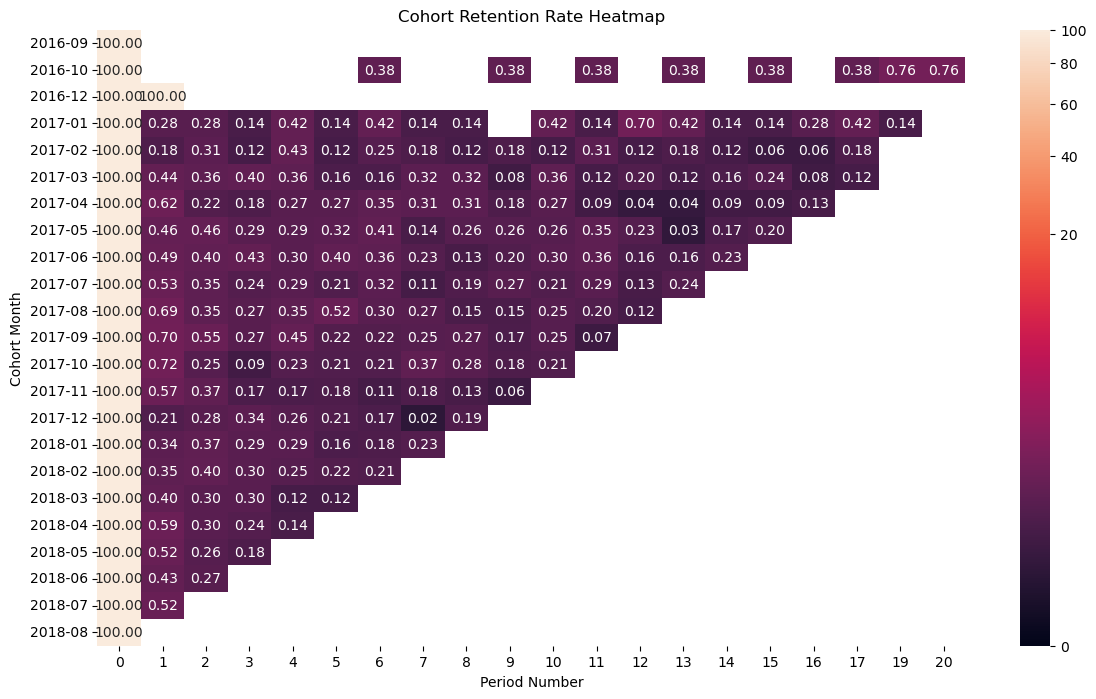

In [42]:
from matplotlib.colors import PowerNorm

plt.figure(figsize=(14, 8))

sns.heatmap(retention_pivot,annot=True,fmt=".2f",
    norm=PowerNorm(gamma=0.25,vmin=0, vmax=100))

plt.title("Cohort Retention Rate Heatmap")
plt.xlabel("Period Number")
plt.ylabel("Cohort Month")
plt.savefig("retention_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Average Retention Curve

The average retention rate is visualized across retention periods to show how customer retention changes over time.
The values were calculated in SQL in Q8. Python is used only to visualize the SQL result.

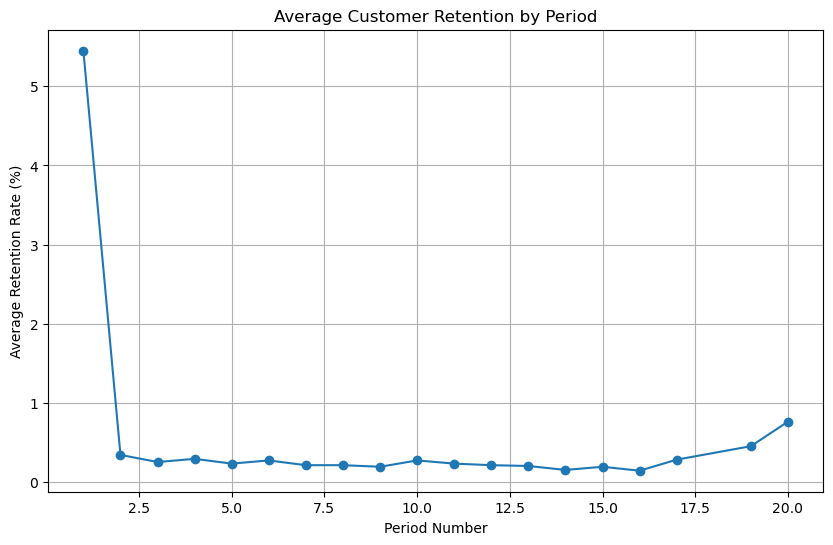

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(average_retention["period_number"], average_retention["average_retention_rate"],marker="o")
plt.title("Average Customer Retention by Period")
plt.xlabel("Period Number")
plt.ylabel("Average Retention Rate (%)")
plt.grid(True)
plt.savefig("average_retention_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Cohort Size Distribution

The cohort size chart shows the number of customers who entered each monthly cohort.


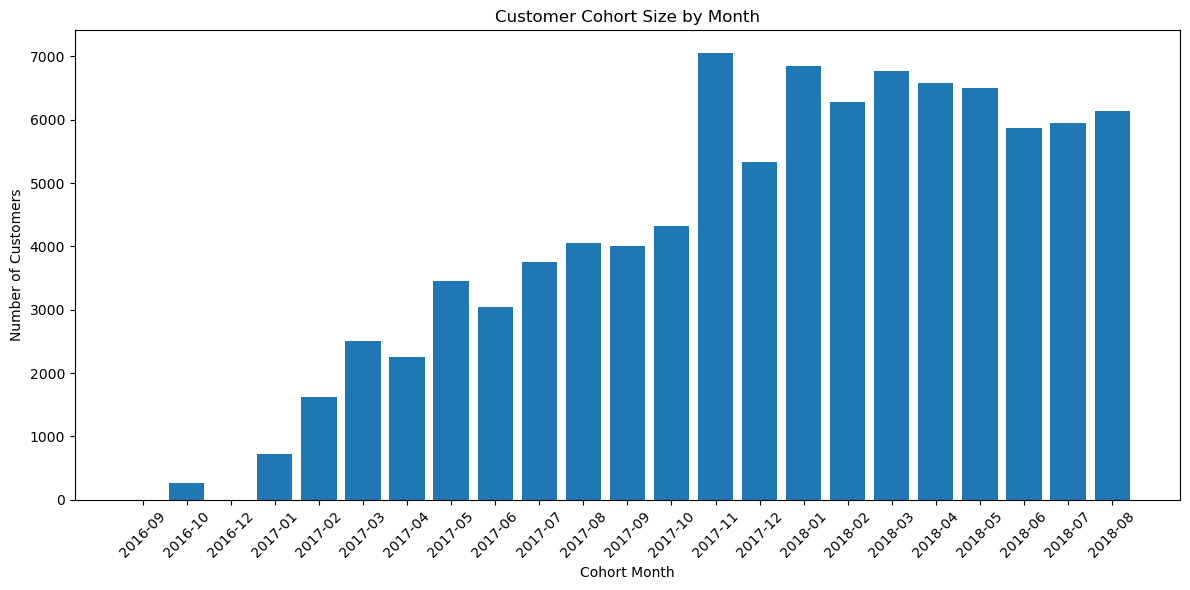

In [44]:
plt.figure(figsize=(12, 6))

plt.bar(cohort_size["cohort_month"],cohort_size["cohort_size"])
plt.title("Customer Cohort Size by Month")
plt.xlabel("Cohort Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("cohort_size_chart.png", dpi=300, bbox_inches="tight")
plt.show()